# TB Detection using CNN Architecures

1. **Setting Up Environment**

1.1. Importing Essential Libraries

In [2]:
import os
import zipfile
import random

from PIL import Image

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D


* os is imported to load the kaggle datasets inside the collab environment with the help of its linux based CLI(Command Line Interface), which helps in  creation of new  folders, rename files,check if files exist and to manage directories.
* Since, kaggle datasets is downloaded as zip, the builtin module of python (zipfile) helps to open and extract it.
*  PIL(Python Image Library) is imported from the image module to open and process the X-ray images.
* Numpy is imported to peform the operations within the image and handle the image data, since images are represented in pixel values.
* pyplot module of Matpotlib is imported for displaying the images, plotting graphs and visualization of training results.
* as a main deep learning framework, tensorflow is imported to build, train and evaluate the models.
* for the processing and augmentation of the images ImageDataGenerator is imported.

*   Different Layers which is required to build the complete CNN, is imported. such as Conv2d, MaxPooling, Flatten, Dense, Dropout and Global Average Pooling2d.











1.2. Accessing Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
#it connects google drive to content

Mounted at /content/drive



* Google drive is mounted with collab so that results, graphs and trained models are saved even after collab session ends since collab storage is temporary.
* It is also used to access the TB dataset, using the Kaggle.json(API) which contains credentials such as username and password, which helps in accessing dataset directly from collab.



1.2.Setting up Kaggle Credentials

In [4]:
os.makedirs('/root/.kaggle', exist_ok=True)

!cp /content/drive/MyDrive/TB_Screening_Project/kaggle.json /root/.kaggle/kaggle.json
#it helps in loading the large kaggle datsaets inside root directory without needing to manually load large zip file.


*   **os.makedirs()**: is a function which helps in creation of a new folder,
*   **exist_ok**: checks if folder exist and if it does, it prevents from throwing an error.
*   **!**: helps to run the linux terminal inside collab
*   **cp**: copies the kaggle.json(credentials) from path to .kaggle(Folder) inside root folder.



1.3. Downloading the Kaggle Dataset of TB

In [5]:
!pip install -q kaggle
# it installs the Kaggle package using python package manager(pip)

# Downloads the dataset using its Kaggle identifier
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset -p /content/tb_dataset

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
100% 663M/663M [00:17<00:00, 38.8MB/s]




* It installs the kaggle package which consists of Kaggle Comand Line Interface.
* It helps in downloading kaggle dataset using download(CLI).
* **-q:** hides the installation messages.
*  **!kaggle datasets download -d**:downloads datasets from kaggle, from given path (-p) and saves the file in tb_dataset folder.



1.4. Extracting the dataset

In [6]:
with zipfile.ZipFile(
    '/content/tb_dataset/tuberculosis-tb-chest-xray-dataset.zip',
    'r') as zip_ref:
    zip_ref.extractall('/content/tb_dataset')

* **zipfile**: it is a module which contains **Zipfile** class, and with it's method **.extractall()**, zip file is extracted.
*   it opens up the zip file and extracts all the dataset inside tb_dataset folder.


In [7]:
# Dataset folders
base_path = "/content/tb_dataset/TB_Chest_Radiography_Database"

normal_folder = os.path.join(base_path, "Normal")
tb_folder = os.path.join(base_path, "Tuberculosis")

# Lists of all image filenames
normal_files = os.listdir(normal_folder)
tb_files = os.listdir(tb_folder)

print("Normal Images:", len(normal_files))
print("Tuberculosis Images:", len(tb_files))

Normal Images: 3500
Tuberculosis Images: 700


* The location of the extracted tuberculosis data is stored in base_path variable.
* **os.path.join()**: method of os.path module is used to identify and combine the multiple folder names and file names within a single file path.
* **os.listdir()**: method is used to list all the images file within a folder Normal  and Tuberculosis.
* all the images of Tuberculosis and Normal is stored in **normal_files** and **tb_files**.


2. Dataset Overview

2.1. Verifying the Dataset

Listing of the folders and files inside TB_Chest_Radiography_Database is done to identify if  the extraction of the data from kaggle were successful,and to make sure the folder which contains the data is accessible.

In [8]:
print(os.listdir(base_path))

['Normal.metadata.xlsx', 'Tuberculosis.metadata.xlsx', 'Tuberculosis', 'Normal', 'README.md.txt']


* **os.listdir()**:  function is used to list the files and folders present inside TB_Chest_Radiography_Database folder.

here, it shows that the dataset contains files with additional information about dataset:
1. Normal.metadata.xlsx.
2. Tuberculosis.metadata.xlsx.
3. README.md.txt.

 Dataset containing X-ray images is present in Tuberculosis and Normal folders.

*   Tuberculosis: represent X-ray images containing images of tuberculosis patients
*  Normal: represents X-ray images containing the images of normal patients






2.2. Counting Total Images

In [9]:
normal_count = len(normal_files)
tb_count = len(tb_files)
print("Normal Images:", normal_count)
print("Tuberculosis Images:", tb_count)

Normal Images: 3500
Tuberculosis Images: 700



* **len()**: lists out the number images within each folder.

here, we can see that total dataset contains about 4,200 images while among them 3,500 are from Normal X ray images, where as 700 is from X-ray images of patients with tuberculosis.
Normal class has higher images in comparison to Tuberculosis class which shows that this dataset is imbalanced.
Due to which CNN model might learn to predict majority class 'Normal' more frequently, which might reduce the models ability to identify the cases of tuberculosis. hence, it will be considered during model training.


2.3. Checking Image Size

In [10]:
# Opening the first Normal image.
image_path = os.path.join(normal_folder, normal_files[0])
image = Image.open(image_path)

print("Image Size:", image.size)
print("Image Mode:", image.mode)

Image Size: (512, 512)
Image Mode: RGB


X-ray images are opened and processed with the help of PIL(pillow library) Image class, and os module to open a sample image of Normal class and identify it's properties such as dimension and it's color before training the CNN model with the images.
* **os.path.join()**: method of os.path module is used to identify and combine the multiple folder names and file names within a single file path.
* **os.listdir()**: method is used to list out all the images file within a folder Normal which is inside base_path. where first image[0] is selected and a new file path is created.
* **Image.open()**: is used to open the selected image.

here, we can identify that the image contains dimension of 512px of width and 512px of hieght. the image is in (RGB), Red, Green, Blue channels. which suggests that during preprocessing it requirest to be resized since the CNN model will be compared with the MobileNetV2, which is pre trained model on ImageNet with dimension of 224 widh of px and 224px of  height.





3. Exploratory Data Analaysis(EDA)

3.1. Class Distribution

> Normal X-ray & Tuberculosis X-ray Images



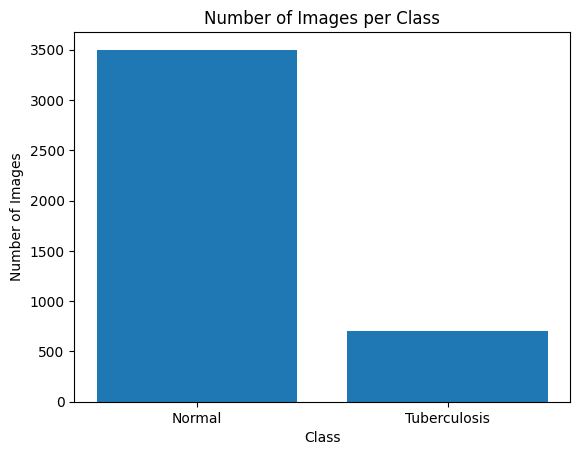

In [11]:
plt.bar(
    ["Normal", "Tuberculosis"],
    [len(normal_files), len(tb_files)]
)
# it prints the number of images within each Tuberculosis and Normal class.

plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()



*   plt.bar(): function of matpotllib is used to create a bar graph.
 here, len() function is used to print the total number of images within a class, using normal_files and tb_files.
*   plt.title(): function is used to create the title.
*   plt.xlabel(): is used to label the x axis.
*   plt.ylabel(): is used to label the y axis.






The graph clearly shows the class imbalance within the X- ray images data, where normal bar is higher in comparison to tuberculosis, hence if we train the model in this dataset it creates the biasness leaning towards majority class.
hence it will be handled with data augmentation by artificially creating variety within the data.

3.2. Sample Images


* To identify the images within the data, which contains Normal X-ray scans and Tuberculosis X-ray scans of the chest and to understand how much they differ between each other matpotlib module is used.

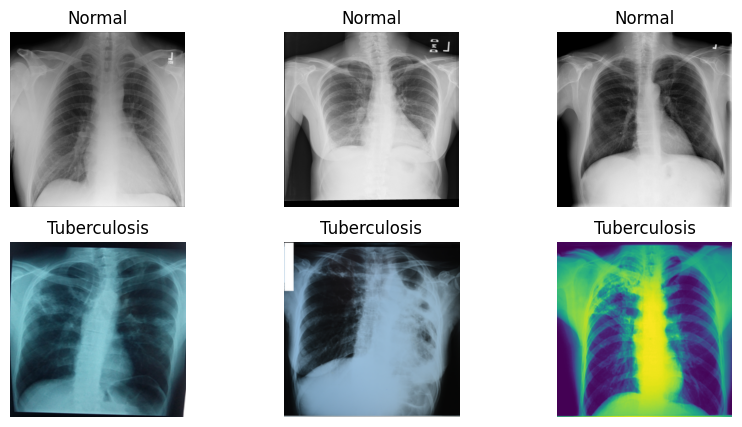

In [12]:
# Show 3 Normal images and 3 Tuberculosis images
plt.figure(figsize=(10, 5))

for i in range(3):
    img_path = normal_folder + '/' + normal_files[i]
    img = Image.open(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title('Normal')
    plt.axis('off')

for i in range(3):
    img_path = tb_folder + '/' + tb_files[i]
    img = Image.open(img_path)
    plt.subplot(2, 3, i + 4)
    plt.imshow(img)
    plt.title('Tuberculosis')
    plt.axis('off')

plt.show()



* with the help of **plt.figure()** function which creates an empty plotting area with the width of 10 inches and heigh of 5 inches, is used to plot the X-ray images.
* to plot the Normal X-ray images for-loop is used, using (PIL) to load in the images into the python memory.




From the images we can clearly see the difference in Normal X-ray images and Tuberculosis X-ray images, where Normal images are in gray scale whereas the Tuberculosis images is presented in color image(RGB).
* The TB images has higher intensity, in respect to lung texture and structural patterns as compared to normal images which has clear lung patterns.
* it shows that the dataset contains the distinct patterns which CNN model can learn during training.





4. DataPreprocessing

4.1. Identifying Corrupted Images


```
# which is not accessible
```



* To identify the corrupt images and to check whether the files in the
dataset are valid and can be opened successfully. Try and Exception method is used, which helps in identification of missing images.

In [13]:
folders_to_check = [
    (normal_folder, normal_files),
    (tb_folder, tb_files)
]

Missing_files_count = 0

for folder, files in folders_to_check:
    for file_name in files:
        file_path = os.path.join(folder, file_name)

        try:
            img = Image.open(file_path)
            img.verify()

        except Exception:
            print("Corrupted file found:", file_path)
            Missing_files_count += 1

print("Total corrupted & Missing files:", Missing_files_count)

Total corrupted & Missing files: 0



* **folders_to_check**: varaiable is created to store the corrupted or missing images, where it stores the Normal, Tuberculosis folders with there respective files in a single list.
* Tuple is used where it contains the folder path and the list of images, which allows both the folders to processed at the same time using the same loop.
* **Missing_files_count**: is initialized to track the number of corrupted images.
* iteration in each folder, files is done using the for loop where folder path is stored in **folder** and **files** stores the list of images filenames.
*   **try** and **except** block is used to access the image, where if there is no error it doesnot throw any exception and if the files are inaccessible or corrupted it throws error.

It helps in the verification of each and every image withing in the folders with the help of **.verify()** and **Image.open()** functions of (PIL) library. hence, the results show that there doesnot exists any corrupted files.





5. Train, Validation and Test Split

```
# of Tuberculosis & Normal Dataset
```





* Folders containing the images are splited with the help of python package **split-folder** which contains **module** **splitfolders**, which automatically split's the datasets into train , validation and test folders.



In [14]:
!pip install split-folders -q
#package which contains splitfolder library which is used to split the folders, automatically.
import splitfolders


splitfolders.ratio(
    base_path,
    output="/content/tb_dataset/split_data",
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)

Copying files: 4200 files [00:00, 5648.69 files/s]



* **.ratio()** function of the split folder is used to divide the folders Tuberculosis and Normal according to the ratio, which copies the splitted folder into new folder split_data.
* **output**: creates the folder split_data where, the splited data is loaded.
* **seed =42**: makes sure that even after running the code multiple times, the splited ratio and image remains the same by initializing the random number generator with fixed value.
* **ratio = (0.8,0.1,0.1)**: is used which is a parameter of the ratio function which takes tuple value which is fixed and divides the dataset of both Tuberculosis and Normal seperelty according to 80% for training, 10% for validation and 10% for testing.

Hence test, train and validation are splitted with the help of split-folder package which contains splitfolder library and it's functions, which is used to divide the ratio of train, validation and split by 80%, 10% and 10%, while making sure even after rerunning the code the images remain the same inside split_data folder, to make sure training and testing is fair and reliable during model training.



6. **Preprocessing**

6.1. Scaling and Data Augmentation

In [15]:
# Path to the split dataset
split_data_path = "/content/tb_dataset/split_data"

# Normalize pixel values to the range [0, 1] & Data Augmentation
datagen = ImageDataGenerator(rescale=1.0 / 255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05)

1. **split_data_path** : is created to store the location of the dataset which is already divided with the help of splitfolder.ratio() function, which consists of Test, Validation and Train folders.
2. Scaling of the pixel value is done with the help of ImageDataGenerator class of Tensoflow keras, where it loads the images in batches(a small chunk of data from the whole data) and scales down between 0 to 1 by dividing the pixel value with 1.
*  it is done to train the ANN (Artificial Neural Networks) to train faster with inputs haiving similar scales. since it prevents the learning patterns being affected by very large pixel values.
* **datagen** is used to store the scaling range defined with the help of ImageDataGenerator object.
3. Since dataset is biased towards Normal cases, data augmentation is done by rotating and shifting the images, and creating new variations which is randomly applied everytime data is loaded.
*   roration_range = 10: images are rotated between -10 degree to + 10 degree., which helps model to learn the X-ray images with slight tilt and makes the model less sensitive towards the small changes in orientation.

*   zoom_range is set to 0.1(10%) which randomly zooms the images by 90% to 110% of the original size.
*   width_shift_range is shifted randomly (5%) of the image width so that images can move approximately 11 pixels left or right. which helps CNN learn images which may vary slightly within the image.

*   height_shift_range is shifted to (5%) which shift images vertically up or down so that images can move 11 pixels upward or downward which helps the CNN learn from even slight differences from patient X-ray images.















In [16]:
train_data = datagen.flow_from_directory(
    os.path.join(split_data_path, "train"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    seed=42
)

val_data = datagen.flow_from_directory(
    os.path.join(split_data_path, "val"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    seed=42
)

test_data = datagen.flow_from_directory(
    os.path.join(split_data_path, "test"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    seed=42,
    shuffle=False
)

Found 3360 images belonging to 2 classes.
Found 420 images belonging to 2 classes.
Found 420 images belonging to 2 classes.


1. function of os module os.path.join() is used to create a accessible path of the training, validation and test folder which was generated with the help of splitfolder library, it is passed to flow_from_directory for easier acess during training the modle.

2. target size is set to 224px of  width and 224 px of height, to resize the images within the dataset in same range and size.

3. color_mode = greyscale, color of the image is set to grey scale(0-255), since there exists Tuberculosis X-ray images with RGB color in dataset, because of which there is a chances that model to classify images with color as tuberculosis, while texture and patterns within the lungs is the determining factor of the tuberculosis.
*   greyscaling the image creates the model to learn patterns, and textures instead of color to determine tuberculosis.

4. Batch size is set to 34, which helps in processing of images before updation of the weights.


*  The training dataset consists of 3360(2800 Normal and 560 Tuberculosis) hence each epoch will consist of 3360/32 = 105 batches.
* Validation dataset and Test datset contains 420 images after splitting (350 Normal and 70 tuberculosis) hence each epoch will consists of 14 batches each.

5. classmode is set to binary since there are only two classification, Normal and Tuberculosis, hence Normal is set to 0 and Tuberculosis is set to 1.

6. shuffle is set to false since with shuffled images the predictions won't match orginial order of the images which makes the evaluation difficult.


7. It is kept to make sure that predicted labels is correspondent to the actual labels during model evalution and performance analysis.

7. Development of CNN Model

7.1. Building CNN architecture

In [17]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

* **Sequential()** : class of keras is used to recive the output of the layers, where each layer is exectued one layer after another and each layer recives the output of the previous layers.

For the first layer of Convolution, **Conv2d()** input_size of 224 px of height and 224 px of width with 3 as a RGB image is taken, since TB-X ray images contained with color(RGB) and to compare, CNN with MobileNetV2 RGB is used for fair comparison.


*   32 filters is used to map the features of different, textures, edges and curves within an image, where each filter slides across the and mapped 32 features are grouped togther and passed to the next layer.
*  Relu function is sued to identify key information, by keeping positive values as it is and negative to 0.
*  MaxPooling for every feature maps is done by selecting maximum largest value from the small region and sliding the kernel 2x2 by 2 steps, which keeps the important features while reducing the size of the image.

for the second layer of Convolution, which takes 32 feature maps from first layers is applied with 64 filters, which learns more complex patterns. likewise third layer takes input of the 64 feature maps from second layers and processes it into 128 feature maps detecting even more complex patterns which is usefull for classification.

the 128 feature maps are converted into a single 1 Dimension vector for (ANN) Artificial Neural Networks to learn combination of the features to make a prediction. **Dense()** Neural Netwoks consist of 128 hidden layers, hence **Dropout(0.5)** is used to turnoff the 50% of the neurons randomly in hidden layer so that it prevents mode from overfitting.

Sigmoid activation function is used to convert the prediction between 0 and 1 to classify between Normal and Tuberculosis.









7.2. Compiling The CNN

In [18]:
cnn_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

compile() method is used to configure the model, with loss function, optimizers and evalutation metric before training of the CNN model,
*  Binary Cross Entropy loss is used, since there are only two binary classes Normal and Tuberculosis, which helps the loss compare between actual label and predicted label accurately.
*  Adam optimizer is used to update the wieghts after every batch, instead of every single training which helps to reduce the loss.
*  Accuracy is set as a metrics to measure performance of the model.






7.3.Using MobileNetV2Model

In [19]:
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 without its original top layers, using ImageNet weights
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Freeze the base model so we don't retrain its existing learned features
base_model.trainable = False

mobilenet_model = Sequential()
mobilenet_model.add(base_model)
mobilenet_model.add(GlobalAveragePooling2D())
mobilenet_model.add(Dense(128, activation='relu'))
mobilenet_model.add(Dropout(0.5))
mobilenet_model.add(Dense(1, activation='sigmoid'))

mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

from tensoflow.keras.application MobileNetV2 is imported which is a pre trained model. it is trained on imageNet, which consists of millions of every day images hence instead of learning from scratch it automatically detects, edges, line, shapes, curves textues and object patterns.

**weights=imageNet**: it learns by using the weights which was learned by training large number of images, instead of starting randomly which helps in extraction of meaningful features.

Since the MobileNetV2 has been trained to predict from large number of images, **include_top=false** but since we have only two classification between Normal X-ray images and Tuberculosis X-ray images. hence, original classification of MobileNetV2 is removed where only the feature extractions and it's trained weights remain.

base_model.trainable = false, is set to that it's learned filters stay exactly the same where only new dense layer learn with it's ability which is trained on large set of data from ImageNet.

**GlobalAveragePooling2D()**: is used to convert the feature maps in of 3D which is produced by MobileNetV2 during training, to single 1D feature vector by averaging the values within each feature channels. which helps in dense layer classification.

the ANN is set to as exactly as CNN, with 128 hidden layers and with relu activation function and dropout which is set to (50%) to randomly disable the neurons during training so that the model doesn't overfits in the trainind data.
Sigmoid activation function is used to predict the final outcome, as either Normal or Tuberculosis.






7.4. Compiling MobileNet V2

In [20]:
mobilenet_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

since, we are predicting binary classification problem hence Binary Cross Entropy loss is used, to predict the loss, here, optimizer and metrics are used as same as CNN model since we are comparing the prediction of MobileNetV2 and CNN model on TB datasets.

8. Training

8.1. Configuring Module Checkpoints

In [21]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Path to save the best CNN model
cnn_model_path = "/content/drive/MyDrive/TB_Screening_Project/best_cnn_model.keras"

# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Save the model with the lowest validation loss
cnn_checkpoint = ModelCheckpoint(
    cnn_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

Callbacks are used here to make sure that the training process is managed and monitored automatically during each complete pass through of the dataset.

**cnn_model_path**: is created to save the best CNN model during training.

EartlyStopping and ModelCheckPoint is used to stop training if the validation loss doesnot improve during training on specified epochs and to automatically save the model during training.
here,
monitor ="val_loss": helps in tracking of the validation loss after each epoch.
**pateince= 3**: is set so that, even after there is no improvement in loss it waits for 3 epochs before terminating the trianing session.

**restore_best_weights** = True: is set so that model only saves when the validation loss improves which makes sure that the best performing model is saved.

**verbose =1**: is used to show the message whenever the model is saved during training.




8.2.CheckPoint for MobileNetV2

In [22]:
# Path to save the best MobileNetV2 model
mobilenet_model_path = "/content/drive/MyDrive/TB_Screening_Project/best_mobilenet_model.keras"

# Save the model with the lowest validation loss
mobilenet_checkpoint = ModelCheckpoint(
    mobilenet_model_path,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


Callbacks are used to save models and monitor in MobileNetV2 training just like in CNN.
here, **mobilenet_model_path** saves the best model during training, and validation loss helps in monitoring the improvement of the model, and if it doesnot improve early stops further training, which reduces the chances of overfitting.


8.3.Training The CNN

In [23]:
# Train the CNN model and store the training history
cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, cnn_checkpoint],
    class_weight={0: 1.0, 1: 5.0}

)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7595 - loss: 1.3757
Epoch 1: val_loss improved from None to 0.47355, saving model to /content/drive/MyDrive/TB_Screening_Project/best_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TB_Screening_Project/best_cnn_model.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.7842 - loss: 0.9759 - val_accuracy: 0.7310 - val_loss: 0.4735
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8081 - loss: 0.6677
Epoch 2: val_loss improved from 0.47355 to 0.14071, saving model to /content/drive/MyDrive/TB_Screening_Project/best_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TB_Screening_Project/best_cnn_model.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.8438 - loss: 0.5737 - val_accuracy: 0.9452 - val_loss: 0.1407
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9045 - loss: 0.4043
Epoch 3: val_loss did not improve from 0.14071

8.4. Training The MobileNetV2

In [24]:
# Train the MobileNetV2 model and store the training history
mobilenet_history = mobilenet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop, mobilenet_checkpoint],
    class_weight={0:1, 1:5}
)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.8999 - loss: 0.4046
Epoch 1: val_loss improved from None to 0.04405, saving model to /content/drive/MyDrive/TB_Screening_Project/best_mobilenet_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TB_Screening_Project/best_mobilenet_model.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 107s 988ms/step - accuracy: 0.9452 - loss: 0.2391 - val_accuracy: 0.9857 - val_loss: 0.0441
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.9784 - loss: 0.1058
Epoch 2: val_loss did not improve from 0.04405
105/105 ━━━━━━━━━━━━━━━━━━━━ 103s 977ms/step - accuracy: 0.9795 - loss: 0.0967 - val_accuracy: 0.9833 - val_loss: 0.0604
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.9750 - loss: 0.0998
Epoch 3: val_loss improved from 0.04405 to 0.03106, saving model to /content/drive/MyDrive/TB_Screening_Project/best_mobilenet_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/TB_Scree



* **cnn_history** & **mobilenet_history **is created to store the training history which is returned by **fit()** method after training the model.
*  **validation_data =val_data:** helps in testing the validation to check the perfromance of the modle after each epoch which helps in understanding if model is learning or only memorizing the data during training.
*  epoch is set to 15, so that model trains and learns essential featues on whole dataset 15 times.
*  **callbacks=[early_stop, cnn_checkpoint]**, is called to monitor the training process.
* since the dataset is imbalanced, **class_weight={0:1.0, 1:5.0}** is used, so that the mistake to classfiy tb cause contribution 5 times more to the loss than that of Normal cases, so that model correctly identifies TB cases.



9.Evaluation of the Modle

9.1.Accuracy & Loss curves

In [25]:
def plot_training_history(history, model_name):
    # Accuracy graph
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss graph
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

pyplot module of matpotlib library is used to plot the graphs and display the graphs of training validation accuracy and loss which is obtained from training.plt.

*  figure() is used to create a new graph to plot the figures.

*  plt.plot() method is used to plot the accuracy and loss in a line graph.

*  plt.title()  function of the pyplot is used to add the  title, and plt.xlabel() has been used to label the x axis as Epoch and plt.ylabel() to labely axis as loss in the graph.

*  plt.show() function has been used to to display the graphs.






9.2. MobileNetV2 plots

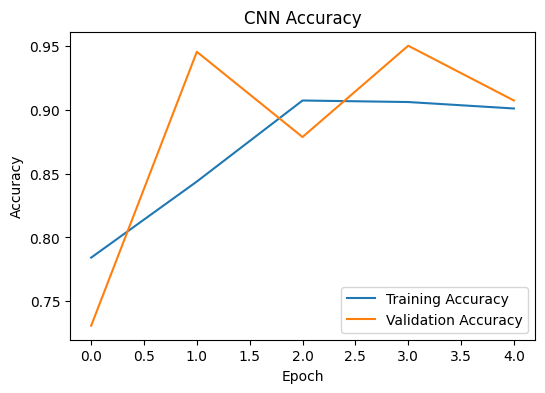

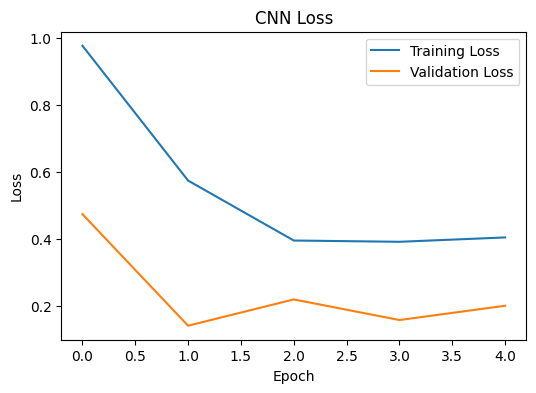

In [26]:
plot_training_history(cnn_history, "CNN")

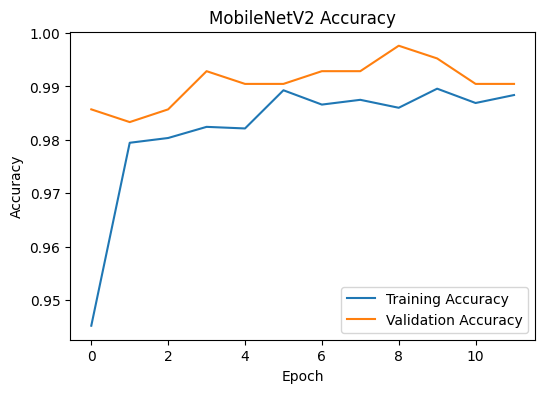

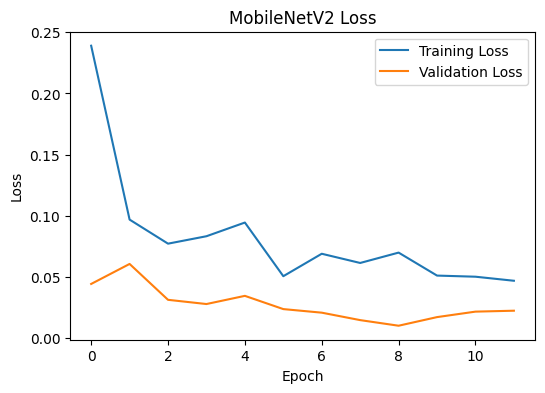

In [28]:
plot_training_history(mobilenet_history, "MobileNetV2")

9.3.Test Set Evaluation

In [29]:
# Actual labels from the test dataset
true_labels = test_data.classes

# Predicted class labels using the CNN model
cnn_predictions = (cnn_model.predict(test_data) > 0.5).astype(int).flatten()

# Predicted class labels using the MobileNetV2 model
mobilenet_predictions = (mobilenet_model.predict(test_data) > 0.5).astype(int).flatten()

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 556ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 815ms/step




* **true_labels = test_data.classes:** it consists of the class labels (Normal or Tuberculosis) of the test dataset. This actual labels are used in comparison with the predicted labels in order to validate the performance of the model.

* **cnn_model.predict(test_data)**: it uses the CNN Model which is trained(during training) and it predicts the probability of the each test image which helps in identifaction of which image belongs to the tuberculosis class.

*  **(cnn_model.predict(test_data) > 0.5)**: is used to compare the predicted probabilities with the defined threshold of 0.5. since if the value of the predicted probability is above 0.5, it assigns a class label as tuberculosis (1) otherwise it labels the class as Normal(0).

* .**astype(int)**: function is used to change the boolean labels (True or False) to integer labels as (1 and 0).

* **.flatten()**: is used to convert the prediction labels in one dimensional array which helps in comparing with actual labels.

* The final prediction labels  made by the CNN model between Normal and Tuberculosis(0,1) is stored in the **cnn_predictions** variable.

whereas, the prediction made by the MobileNetV2 model on test data is store in **mobilenet_predictions** variable.

9.4. Calculating the Metrics

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(true_labels, predictions, model_name):
    print(f"\n{model_name} Results")
    print("Accuracy:", accuracy_score(true_labels, predictions))
    print("Precision:", precision_score(true_labels, predictions))
    print("Recall:", recall_score(true_labels, predictions))
    print("F1 Score:", f1_score(true_labels, predictions))

    cm = confusion_matrix(true_labels, predictions)
    print("Confusion Matrix:")
    print(cm)

    return cm

from scikit learn which cotains the library to evaluate the models is imported, which helps in detection of accuracy, precision, recall, f1 score and confusion matrix.

a function **evaluate_model** is created which takes **true_labels**, predictions, model_name as the parameters.

* **true_labels** is actual labels of the test images.

* **predictions** is labels which is predicted by the model.

* accuracy_score()**: It is used to make comparisons between true labels (actual labels normal and tuberculosis), and predicted labels (predicted labels by models) and prints the percentage of correct predictions.

* Similarly, the precision_score(), recall_score() and f1_score() have been used to print the performance of the model.


* confusion_matrix (cm):
It has been used to print the true positive, true negative, false positive, and false negatives respectively for actual and predicted labels.




for CNN

In [31]:
cnn_cm = evaluate_model(
    true_labels,
    cnn_predictions,
    "CNN"
)


CNN Results
Accuracy: 0.9357142857142857
Precision: 0.8208955223880597
Recall: 0.7857142857142857
F1 Score: 0.8029197080291971
Confusion Matrix:
[[338  12]
 [ 15  55]]


for Mobile NetV2

In [32]:
mobilenet_cm = evaluate_model(
    true_labels,
    mobilenet_predictions,
    "MobileNetV2"
)


MobileNetV2 Results
Accuracy: 0.9952380952380953
Precision: 1.0
Recall: 0.9714285714285714
F1 Score: 0.9855072463768116
Confusion Matrix:
[[350   0]
 [  2  68]]


evaluate_model function is called where true_labels(labels of test cases)
*  **cnn_prediction**(predicted cases) are passed to identify performance metrics for CNN modle.
*  **mobilenet_predictions** (predicted cases) are passed to identify the perfromance of MobileNetV2 model.

9.5. Plotting the Confusion Matrix

In [33]:
def plot_confusion_matrix(confusion_matrix, model_name):
    plt.figure(figsize=(5, 4))

    sns.heatmap(
        confusion_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Tuberculosis"],
        yticklabels=["Normal", "Tuberculosis"]
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

the function of matpotlib.pyplot(plt)  is used to create and display the confusion matrix graph, where visualization of confusion matrix is done with,


*  **seaborn(sns)** as heatmap which makes the interpretain of models prediction easier.
*  **sns.heatmap()** : is used, to plot the confusion matrix with numerical values and columns.
* **annon=true**: is sued to display the counts inside the box.
* **cmap= "blues"** is used to apply the blue color theme in heatmap.
*  xticklabels and yticklabels helps to label the predicted and actual class, **plt.show()** is used to display the confusion matrix heatmap.

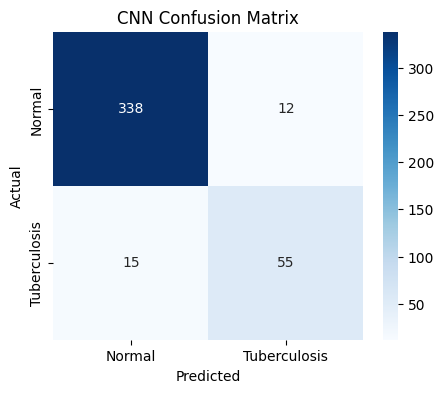

In [34]:
import seaborn as sns
plot_confusion_matrix(cnn_cm, "CNN")

In [ ]:
plot_confusion_matrix(mobilenet_cm, "MobileNetV2")

9.6. Model Comparison

Comparing Model CNN and MobileNetV2

In [35]:
import pandas as pd

comparison_data = {
    "Model": ["CNN (Scratch)", "MobileNetV2"],
    "Accuracy": [
        accuracy_score(true_labels, cnn_predictions),
        accuracy_score(true_labels, mobilenet_predictions)
    ],
    "Precision": [
        precision_score(true_labels, cnn_predictions),
        precision_score(true_labels, mobilenet_predictions)
    ],
    "Recall": [
        recall_score(true_labels, cnn_predictions),
        recall_score(true_labels, mobilenet_predictions)
    ],
    "F1 Score": [
        f1_score(true_labels, cnn_predictions),
        f1_score(true_labels, mobilenet_predictions)
    ]
}

comparison_table = pd.DataFrame(comparison_data).round(4)

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,CNN (Scratch),0.9357,0.8209,0.7857,0.8029
1,MobileNetV2,0.9952,1.0000,0.9714,0.9855


a dictionary of **comparison_data** is created to store the evalutaion metrics of both the CNN and MobileNetV2 models, where **"Model"** stores the name of the model which is being compared.


*   accuracy_score() is used to calculate the accuracy of both the models which is stored in accuracy column.
likewise, precision_score(), recall_score(), f1_score() calculates the respective scores of both the models and stores in respective columns.
*  pd.Dataframe(comparison_data) is used to store the dictionary in pandas Dataframe, which helps in providing the table to compare evaluation metrics.
* for loop is used to display the decimal values of performance of  each model in percentage.
here, comparison_table[col]* 100 converts the demcimal values in percentage.
* round(4) is used to round the data upto four decimal values to compare effectively. comparison_table distplays tthe comparison between Cnn and MobileNetV2 in percentages from.



Simple Bar Chart Comparison

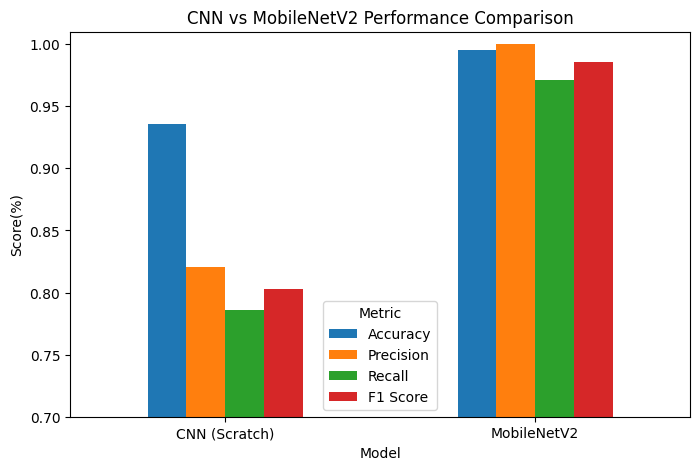

In [36]:
# Comparison of the performance of both the CNN and MobileNetV2 models
comparison_table.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("CNN vs MobileNetV2 Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score(%)")
plt.ylim(0.7, 1.01)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.show()

pyplot is used to plot the graph to compare between CNN and MobileNetV2,
here, **figsize=(8,5)** is use to creat box of 8 inches in width and 5 inches in height which helps in reading tthe bar graph easily.


* **plt.ylim(90, 101):** is used to set the X- axis between 90% to 101% so that it is easier to read the small differences between the models easier to read.
* **plt.xticks(rotation=0)**: is used to show the name of the x-axis horizontal which makes it easier and visually attractive.



10. Project Demo Using Gradio.

10.1. Installing Gradio

---



In [37]:
!pip install -q gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.0/31.0 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.1/130.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.0/134.0 kB 15.7 MB/s eta 0:00:00


Gradio which is one of the Python Library is used to create a simple web based interface to Load the X-ray image and Predict Tuberculosis or Normal.

10.2. Importing Libraries

In [38]:
import gradio as gr
import numpy as np
import tensorflow as tf

from PIL import Image
from tensorflow.keras.models import load_model



*   **gradio** is imported as **gr** which helps in creating in interactive dashboard which allows to upload chest X-ray images and recieve tuberculosis predictions.
*  **numpy** is imported to perform numerical operation and tensorflow since, MobileNetV2 model is trained to tensorflow which helps in loading and running the model.

*  **Image** is imported from the** PIL** library which helps to resize and format the images of X-ray.

*  **load_model** is imported to load the model which is developed using MobileNetV2 to make predictions of chest X-ray images.

here **MobileNetV2** is used over **CNN** because, it provided better perfomance in comparison to CNN.


10.3. Loading The Best Model

In [39]:
model = load_model("/content/drive/MyDrive/TB_Screening_Project/best_mobilenet_model.keras")


with the help of load_model() function, the trained best MobileNet model on tuberculosis images is loaded which was saved on googldrive.

10.4. Creating Prediction Function

In [40]:
def predict_tb(image):

    # Resizing the image
    image = image.resize((224, 224))

    # Converting to RGB
    image = image.convert("RGB")

    # Converting image to numpy array
    image = np.array(image)

    # Normalizing pixel values
    image = image / 255.0

    # Adding batch dimension
    image = np.expand_dims(image, axis=0)

    # Predict probability
    probability = model.predict(image, verbose=0)[0][0]

    if probability >= 0.5:
        prediction = "Tuberculosis"
        confidence = probability * 100
    else:
        prediction = "Normal"
        confidence = (1 - probability) * 100

    return (
        prediction,
        f"{confidence:.2f}%",
        f"{probability*100:.2f}%"
    )

predict_tb(image) function is created to process the uploaded image and to predict if it falls under Tuberculosis or Normal Section.

*   image.resize() is used to resized the uploaded image, to make sure that it falls under the same size as MobileNetV2 image trained pixel size.

*  image.convert("RGB") is used to convert the image in RGB since the MobileNetV2 is trained on RGB images and also since, the tuberculosis images are present in RGB.

* np.array(image) is used to converts the images to Numpy array so that it is readable   by the ANN.

*  modle.predict() function calls the MobileNetV2 model and predicts the class of the uploaded images(Tuberculosis or Normal)

*  [0],[0] is used to extract the value which is predicted from the returned prediction array.

*  Thresholding is done using if else statement where if probability > 50% then images is classified as Tuberculosis otherwise Normal.


10.5. Building The Interface to Load Images

In [42]:
demo = gr.Interface(
    fn=predict_tb,
    inputs=gr.Image(type="pil", label="Upload Chest X-ray Image"),
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Confidence"),
        gr.Textbox(label="Raw Probability")
    ],
    title="Tuberculosis Detection using MobileNetV2",
    description="Upload a chest X-ray image to predict if it shows signs of Tuberculosis or is Normal."
)
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8c27725fc2459b2e38.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


* gr.interface() which is one of the Gradio libray class is used to create an web based interface which connects to the MobileNetV2 model,
MobileNetV2 model is used, instead of CNN since by looking at performance metric, MobileNetv2 performed far better as compared to CNN model.
* fn = predict_tb: helps to run predit_tb() function whenever the chest X-ray images is loaded.
*  inputs=gr.Image(type="phil") is used to create the image upload section which accepts the images and passes it to predict_tb () function as a PIL(Python Image Library) image.
* output is used to display the result by creating three boxes to display the predicted class, confidence score and the raw probability returned by the model.




